# Freight Rate Prediction

**Goal:** Predict `posted_rate` for the 12,000 November–December 2025 loads in `validation.csv` and generate daily predictions for the fixed Lexington → Fort Wayne lane during December 2025.

### Notebook outline

1. Setup and data loading
2. Exploratory data analysis
3. Data-quality treatment and feature engineering
4. Nested temporal validation design
5. LightGBM model selection using pre-test folds
6. Untouched September–October model assessment
7. Final January–October training and validation predictions
8. Fixed-lane December predictions
9. Structural validation with the supplied scorer

**Final evaluation:** After all preprocessing decisions and model settings were fixed using pre-September data, the selected pipeline achieved a September–October MAE of **$119.89**, RMSE of **$637.10**, and R² of **0.8257**.




## 0. Setup & data loading


In [1]:
import pandas as pd

DATA_DIR = "data"
train_raw = pd.read_csv(f"{DATA_DIR}/train-test.csv", parse_dates=["date"])
val_raw = pd.read_csv(f"{DATA_DIR}/validation.csv", parse_dates=["date"])
december_raw = pd.read_csv(
    f"{DATA_DIR}/december-chart-inputs.csv", parse_dates=["date"]
)
template = pd.read_csv(f"{DATA_DIR}/validation-predictions-template.csv")

print("train_test:", train_raw.shape)
print("validation:", val_raw.shape)
print("december  :", december_raw.shape)
train_raw.head()

train_test: (48000, 14)
validation: (12000, 13)
december  : (31, 7)


,load_id,pickup,delivery,pickup_lat,pickup_lon,delivery_lat,delivery_lon,distance,equipment,weight,date,market_index,quote_signal,posted_rate
0,TR-000001,Richmond,Baltimore,38.09122,-76.78906,38.16908,-72.74564,274.3,Dry Van,30658.0,2025-01-01,0.95684,2.39595,645.41
1,TR-000002,Richmond,Philadelphia,38.09122,-76.78906,39.22317,-72.96710,280.5,Reefer,17555.0,2025-01-01,0.97623,2.43355,679.97
2,TR-000003,Philadelphia,Green Bay,39.22317,-72.96710,44.30296,-87.52871,967.8,Dry Van,31721.0,2025-01-01,1.00971,1.84491,1802.54
3,TR-000004,Hartford,Atlanta,39.55328,-72.18051,34.84933,-86.28940,965.4,Dry Van,32333.0,2025-01-01,0.94518,1.87712,1827.28
4,TR-000005,Dallas,Nashville,31.83025,-94.38343,35.29479,-88.08915,541.9,Reefer,35183.0,2025-01-01,0.98480,2.56300,1380.28


## 1. Exploratory Data Analysis

In [2]:
train_raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48000 entries, 0 to 47999
Data columns (total 14 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   load_id       48000 non-null  object        
 1   pickup        48000 non-null  object        
 2   delivery      48000 non-null  object        
 3   pickup_lat    48000 non-null  float64       
 4   pickup_lon    48000 non-null  float64       
 5   delivery_lat  48000 non-null  float64       
 6   delivery_lon  48000 non-null  float64       
 7   distance      48000 non-null  float64       
 8   equipment     48000 non-null  object        
 9   weight        47700 non-null  float64       
 10  date          48000 non-null  datetime64[ns]
 11  market_index  47626 non-null  float64       
 12  quote_signal  48000 non-null  float64       
 13  posted_rate   48000 non-null  float64       
dtypes: datetime64[ns](1), float64(9), object(4)
memory usage: 5.1+ MB


`market_index` has 374 missing values and `weight` has 300 missing values.

In [3]:
val_raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12000 entries, 0 to 11999
Data columns (total 13 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   load_id       12000 non-null  object        
 1   pickup        12000 non-null  object        
 2   delivery      12000 non-null  object        
 3   pickup_lat    12000 non-null  float64       
 4   pickup_lon    12000 non-null  float64       
 5   delivery_lat  12000 non-null  float64       
 6   delivery_lon  12000 non-null  float64       
 7   distance      12000 non-null  float64       
 8   equipment     12000 non-null  object        
 9   weight        11835 non-null  float64       
 10  date          12000 non-null  datetime64[ns]
 11  market_index  11751 non-null  float64       
 12  quote_signal  12000 non-null  float64       
dtypes: datetime64[ns](1), float64(8), object(4)
memory usage: 1.2+ MB


Similarly, in validation dataset, `weight` and `market_index` have missing values.

In [4]:
print(
    "Train date range:", train_raw.date.min().date(), "→", train_raw.date.max().date()
)
print(
    "Validation date range:", val_raw.date.min().date(), "→", val_raw.date.max().date()
)
print()

Train date range: 2025-01-01 → 2025-10-31
Validation date range: 2025-11-01 → 2025-12-31



**Key structural fact:** the development data covers **Jan–Oct 2025** while the validation set covers **Nov–Dec 2025**. The final task is *forecasting into the future*, so our own validation split must be temporal (train on earlier months, test on later months) ... a random split would leak future market conditions and overstate performance.

In [5]:
print("Equipment types:", sorted(train_raw.equipment.unique()))
print("Unique pickup cities:", train_raw.pickup.nunique())
print("Duplicate load_ids:", train_raw.load_id.duplicated().sum())
print("Fully duplicated rows:", train_raw.duplicated().sum())

Equipment types: ['Dry Van', 'Flatbed', 'Reefer']
Unique pickup cities: 64
Duplicate load_ids: 0
Fully duplicated rows: 0


In [6]:
print("Equipment types:", sorted(val_raw.equipment.unique()))
print("Unique pickup cities:", val_raw.pickup.nunique())
print("Duplicate load_ids:", val_raw.load_id.duplicated().sum())
print("Fully duplicated rows:", val_raw.duplicated().sum())

Equipment types: ['Dry Van', 'Flatbed', 'Reefer']
Unique pickup cities: 72
Duplicate load_ids: 0
Fully duplicated rows: 0


In [7]:
train_raw.describe()

,pickup_lat,pickup_lon,delivery_lat,delivery_lon,distance,weight,date,market_index,quote_signal,posted_rate
count,48000.000000,48000.000000,48000.000000,48000.000000,48000.000000,47700.000000,48000,47626.000000,48000.000000,48000.000000
mean,35.647545,-90.928964,35.641175,-90.857310,1135.856654,31028.844004,2025-05-31 19:53:29.400000,1.083387,2.062468,2373.980682
min,28.357650,-121.698490,28.357650,-121.698490,70.000000,-47500.000000,2025-01-01 00:00:00,0.676390,0.692280,57.220000
25%,31.986910,-98.400590,31.986910,-98.400590,550.400000,25800.000000,2025-03-18 00:00:00,0.949670,1.891030,1251.555000
50%,35.294790,-88.089150,35.294790,-87.528710,953.300000,31436.500000,2025-05-31 00:00:00,1.055800,2.055750,2030.760000
75%,39.411040,-83.285060,39.411040,-83.285060,1645.525000,37018.000000,2025-08-15 00:00:00,1.219590,2.221685,3330.750000
max,44.302960,-69.500000,44.302960,-69.500000,3439.800000,47500.000000,2025-10-31 00:00:00,1.467780,3.610350,25533.000000
std,4.315285,13.482431,4.317199,13.476589,728.564416,9391.440620,NaN,0.168091,0.291391,1486.493245


array([[<Axes: title={'center': 'pickup_lat'}>,
        <Axes: title={'center': 'pickup_lon'}>,
        <Axes: title={'center': 'delivery_lat'}>],
       [<Axes: title={'center': 'delivery_lon'}>,
        <Axes: title={'center': 'distance'}>,
        <Axes: title={'center': 'weight'}>],
       [<Axes: title={'center': 'date'}>,
        <Axes: title={'center': 'market_index'}>,
        <Axes: title={'center': 'quote_signal'}>],
       [<Axes: title={'center': 'posted_rate'}>, <Axes: >, <Axes: >]],
      dtype=object)

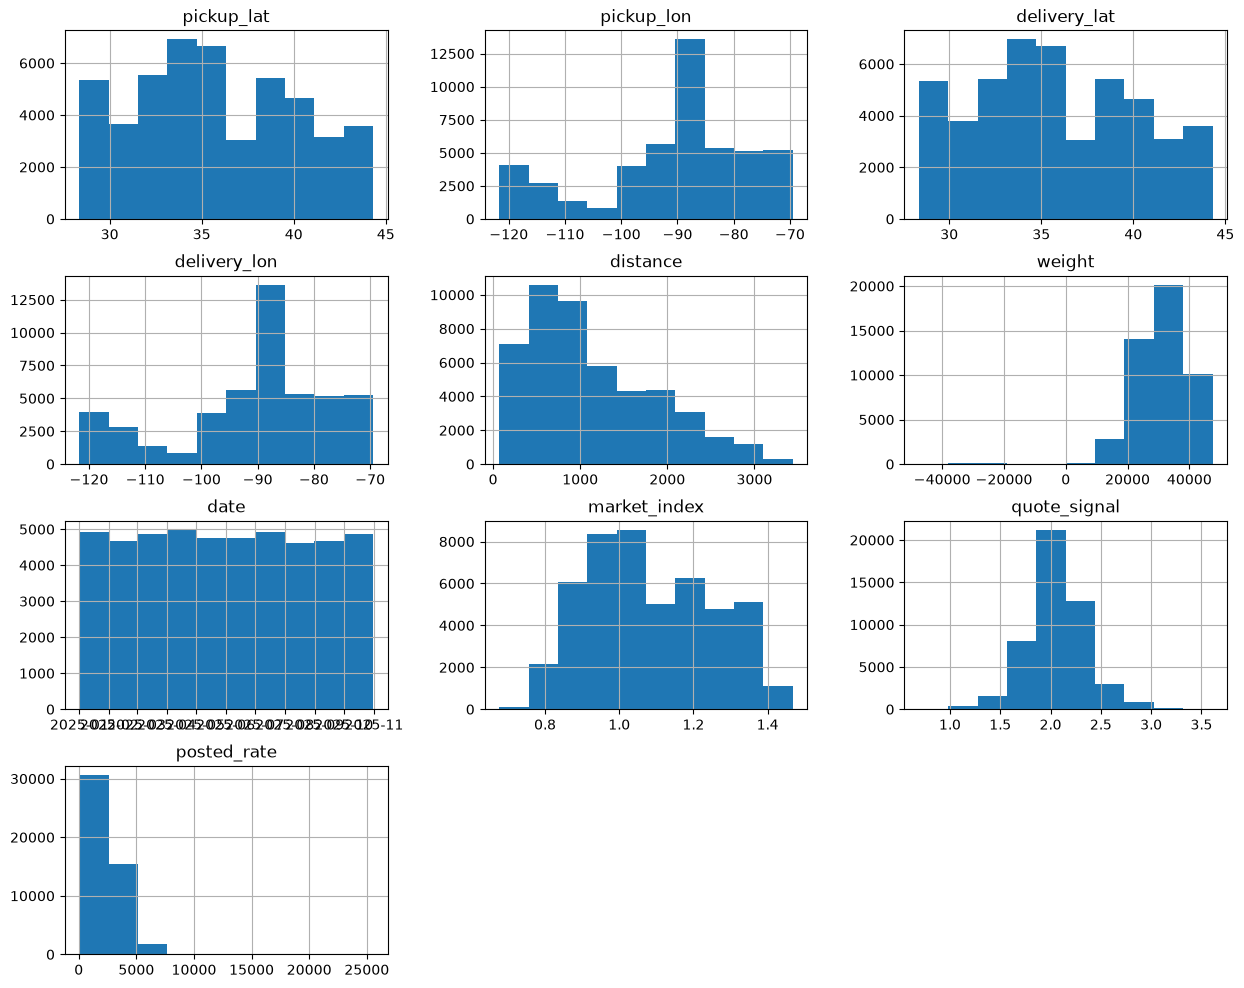

In [8]:
train_raw.hist(figsize=(15, 12))

`weight` seems to have some negative values as well, which are most probably data entry error.

In [9]:
negative_pct = (train_raw["weight"] < 0).sum() / len(train_raw) * 100
print(f"{negative_pct:.2f}% of rows have negative weight in train set")

negative_pct = (val_raw["weight"] < 0).sum() / len(val_raw) * 100
print(f"{negative_pct:.2f}% of rows have negative weight in val set")

0.61% of rows have negative weight in train set
1.21% of rows have negative weight in val set


In [10]:
correlations = (
    train_raw.select_dtypes(include="number")
    .corr()["posted_rate"]
    .sort_values(ascending=False)
)
print(correlations)

posted_rate     1.000000
distance        0.908519
weight          0.034840
market_index    0.034165
quote_signal   -0.039858
pickup_lat     -0.090873
delivery_lat   -0.091970
pickup_lon     -0.255058
delivery_lon   -0.257086
Name: posted_rate, dtype: float64


`posted_rate` has a very high correlation with `distance`, which is expected because longer deliveries generally cost more. Rate per mile is therefore useful for exploring how the remaining variables relate to pricing after accounting for distance.

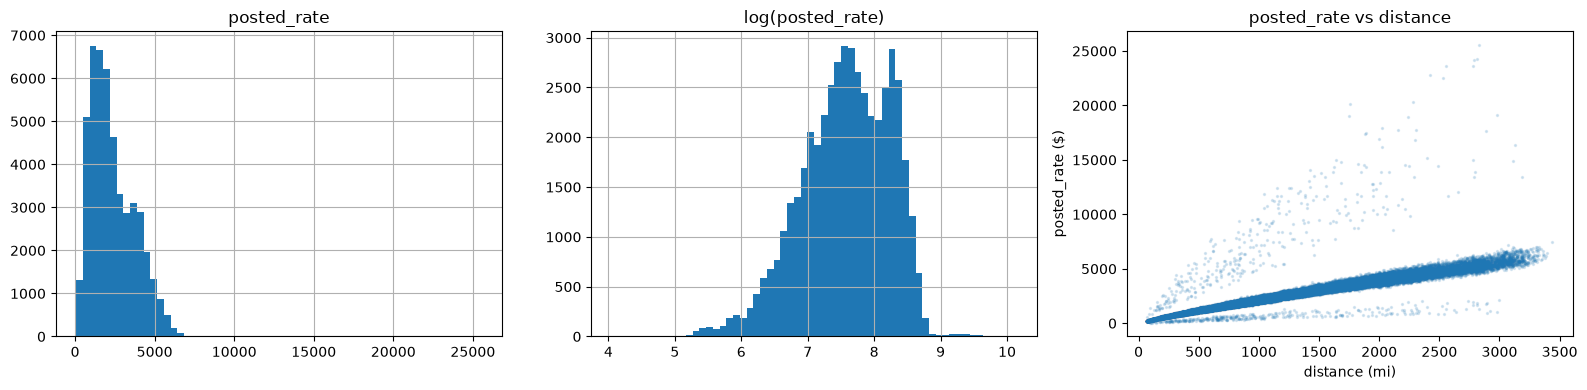

In [11]:
import matplotlib.pyplot as plt
import numpy as np

# Target distribution
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
train_raw.posted_rate.hist(bins=60, ax=axes[0])
axes[0].set_title("posted_rate")
np.log(train_raw.posted_rate).hist(bins=60, ax=axes[1])
axes[1].set_title("log(posted_rate)")
axes[2].scatter(train_raw.distance, train_raw.posted_rate, s=2, alpha=0.15)
axes[2].set_title("posted_rate vs distance")
axes[2].set_xlabel("distance (mi)")
axes[2].set_ylabel("posted_rate ($)")
plt.tight_layout()
plt.show()

The target `posted_rate` is right-skewed, so we model `log(posted_rate)` instead, the log transform makes the distribution roughly normal and easier to fit. It also means the model treats errors *proportionally* (a $100 miss on a $500 load is penalized more than on a $5,000 load), which matches how freight is actually priced: per mile, not as a flat dollar amount.



In [12]:
train_raw["rpm"] = train_raw.posted_rate / train_raw.distance
print(train_raw.rpm.describe())

count    48000.000000
mean         2.215347
std          0.583887
min          0.333709
25%          1.986974
50%          2.145348
75%          2.342696
max         14.125294
Name: rpm, dtype: float64


The rate-per-mile (RPM) has a median of approximately **\$2.15/mi**, with extremes ranging from about \$0.33 to \$14.13 per mile. These observations warrant further investigation; any exclusion will be limited to model-fitting partitions.

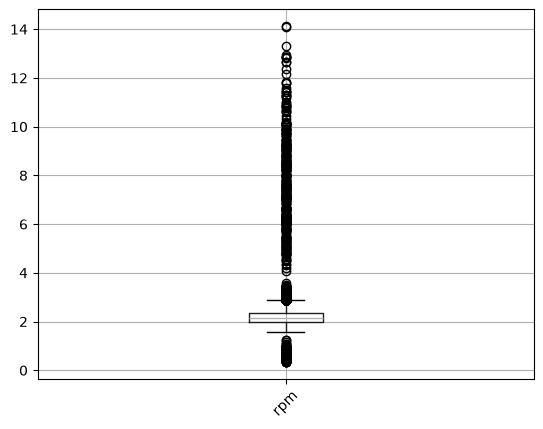

In [13]:
train_raw.boxplot(column="rpm")
plt.xticks(rotation=45)
plt.show()

We'll circle back to dealing with these outliers in section 2.1.
Let's see what drives rate-per-mile.

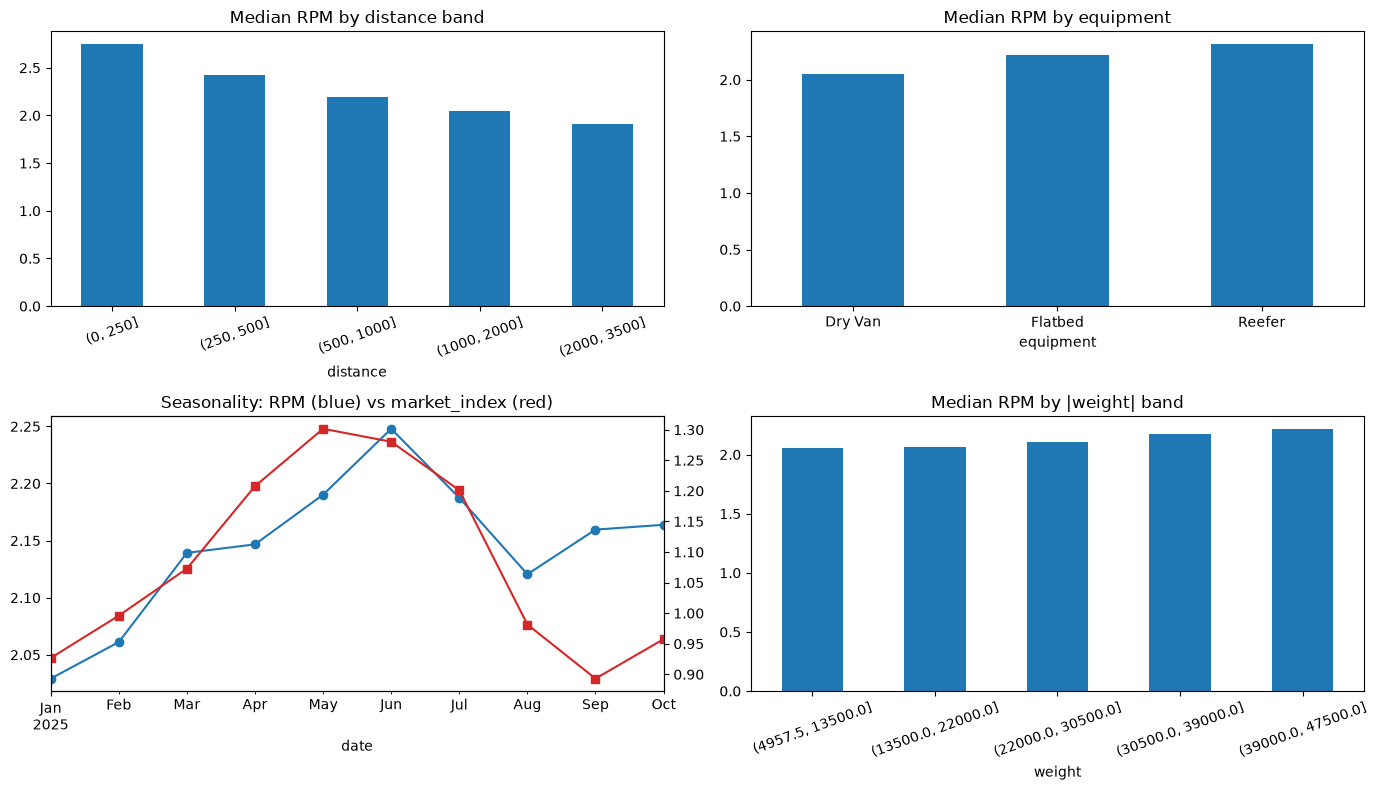

In [14]:
# EDA: what drives rate-per-mile?
fig, axes = plt.subplots(2, 2, figsize=(14, 8))

# 1) distance economies of scale
train_raw.groupby(
    pd.cut(train_raw.distance, [0, 250, 500, 1000, 2000, 3500]), observed=True
).rpm.median().plot(kind="bar", ax=axes[0, 0], rot=20)
axes[0, 0].set_title("Median RPM by distance band")

# 2) equipment
train_raw.groupby("equipment").rpm.median().plot(kind="bar", ax=axes[0, 1], rot=0)
axes[0, 1].set_title("Median RPM by equipment")

# 3) monthly seasonality of RPM and market_index
monthly = train_raw.groupby(train_raw.date.dt.to_period("M")).agg(
    rpm=("rpm", "median"), mi=("market_index", "mean")
)
ax = axes[1, 0]
monthly.rpm.plot(ax=ax, marker="o", label="median RPM")
ax2 = ax.twinx()
monthly.mi.plot(ax=ax2, color="tab:red", marker="s", label="mean market_index")
ax.set_title("Seasonality: RPM (blue) vs market_index (red)")

# 4) weight
train_raw.groupby(pd.cut(train_raw.weight.abs(), 5), observed=True).rpm.median().plot(
    kind="bar", ax=axes[1, 1], rot=20
)
axes[1, 1].set_title("Median RPM by |weight| band")
plt.tight_layout()
plt.show()

**Findings**

1. **Short hauls are much more expensive per mile** (~\$2.75/mi under 250 mi vs ~\$1.91/mi over 2,000 mi).
2. **Equipment matters:** Reefer > Flatbed > Dry Van in RPM.
3. **Seasonality:** rates and `market_index` both peak around May–June and soften into autumn. Crucially, `market_index` is provided for the validation rows, so the model can read Nov–Dec market conditions directly instead of blindly extrapolating a date trend. 
4. **Heavier loads price slightly higher per mile.**


## 2. Data Cleaning

In [15]:
issues = pd.DataFrame(
    {
        "train": [
            (train_raw.weight < 0).sum() / len(train_raw) * 100,
            train_raw.weight.isna().sum() / len(train_raw) * 100,
            train_raw.market_index.isna().sum() / len(train_raw) * 100,
            ((train_raw.rpm < 0.6) | (train_raw.rpm > 8)).sum() / len(train_raw) * 100,
        ],
        "validation": [
            (val_raw.weight < 0).sum() / len(val_raw) * 100,
            val_raw.weight.isna().sum() / len(val_raw) * 100,
            val_raw.market_index.isna().sum() / len(val_raw) * 100,
            np.nan,
        ],
    },
    index=[
        "negative weight",
        "missing weight",
        "missing market_index",
        "extreme RPM outliers (<$0.6 or >$8/mi)",
    ],
)
issues.round(2).astype(str) + "%"

,train,validation
negative weight,0.61%,1.21%
missing weight,0.62%,1.38%
missing market_index,0.78%,2.08%
extreme RPM outliers (<$0.6 or >$8/mi),0.63%,nan%


**How each issue is addressed**

| Issue | Treatment | Rationale |
|---|---|---|
| Negative weights (~0.6% of rows, mirrored magnitudes up to −47,500 lb) | `abs(weight)` | Magnitudes fall exactly in the normal weight range → sign-entry errors, not real values |
| Missing `weight` / `market_index` (<1%) | Leave as `NaN` | Preserve missingness during general cleaning and defer its handling to the selected modeling pipeline, avoiding arbitrary imputation at this stage. |
| Extreme RPM observations (e.g. \$67 for 144 mi or \$4,069 for 306 mi) | Exclude from model fitting only when flagged by a z-score on `log(RPM)` (`\|z\| > 3.5) | These rows may reflect data-entry errors or factors absent from the available predictors. Validation, test, and final prediction rows are never removed. |

In [16]:
def clean(df: pd.DataFrame) -> pd.DataFrame:
    out = df.copy()
    out["weight"] = out["weight"].abs()  # fix sign-entry errors
    return out


train = clean(train_raw.drop(columns=["rpm"]))
val = clean(val_raw)

#### 2.1 Outlier detection with a z-score on log(RPM)

Rate per mile (RPM) is strongly right-skewed, so a conventional z-score on raw RPM is overly influenced by its extreme upper tail. The logarithm of RPM is much more symmetric, making it a more suitable scale for identifying unusually high and low values.

The distribution shows separated observations at both extremes. A fixed cutoff of `|z| > 3.5` on `log(RPM)` is therefore used as a transparent data-quality rule. A median/MAD diagnostic identifies a similar group, providing a robustness check on the pattern.

Because this rule uses the target, its mean and standard deviation are recalculated independently within every model-fitting partition. Flagged observations are excluded only from fitting; inner validation folds, the September–October assessment period, and the final validation data remain complete.


skew of raw RPM: 8.72 | skew of log RPM: -0.04
|z| > 3.0: flags  675 rows | implied RPM bounds $1.21 – $3.88/mi
|z| > 3.5: flags  672 rows | implied RPM bounds $1.10 – $4.28/mi
|z| > 4.0: flags  660 rows | implied RPM bounds $1.00 – $4.72/mi


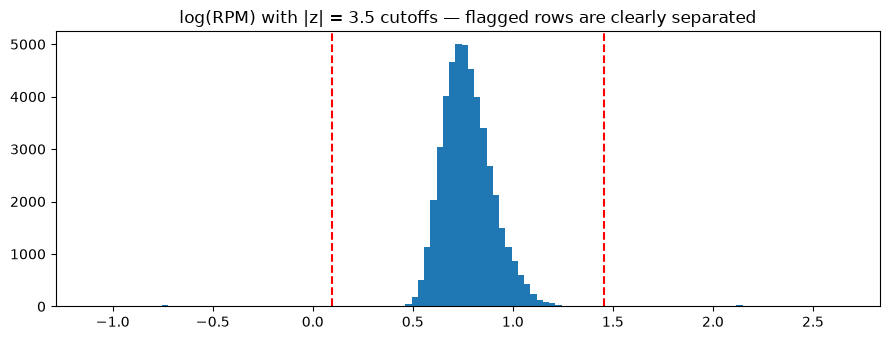

In [17]:
Z_CUTOFF = 3.5


def rpm_outlier_mask(df: pd.DataFrame) -> pd.Series:
    """True for rows to KEEP. Z-score on log(rate-per-mile), stats from df itself."""
    log_rpm = np.log(df.posted_rate / df.distance)
    z = (log_rpm - log_rpm.mean()) / log_rpm.std()
    return z.abs() <= Z_CUTOFF


log_rpm = np.log(train.posted_rate / train.distance)
print(
    f"skew of raw RPM: {(train.posted_rate/train.distance).skew():.2f} | skew of log RPM: {log_rpm.skew():.2f}"
)
for k in [3.0, 3.5, 4.0]:
    z = (log_rpm - log_rpm.mean()) / log_rpm.std()
    lo, hi = np.exp(log_rpm.mean() - k * log_rpm.std()), np.exp(
        log_rpm.mean() + k * log_rpm.std()
    )
    print(
        f"|z| > {k}: flags {(z.abs() > k).sum():4d} rows | implied RPM bounds ${{lo:.2f}} – ${{hi:.2f}}/mi".format(
            lo=lo, hi=hi
        )
    )

fig, ax = plt.subplots(figsize=(9, 3.5))
ax.hist(log_rpm, bins=120)
for s in (-1, 1):
    ax.axvline(log_rpm.mean() + s * Z_CUTOFF * log_rpm.std(), color="red", ls="--")
ax.set_title("log(RPM) with |z| = 3.5 cutoffs — flagged rows are clearly separated")
plt.tight_layout()
plt.show()

In [18]:
train["is_rpm_outlier"] = ~rpm_outlier_mask(train)
print(
    f"Flagged {train.is_rpm_outlier.sum()} of {len(train):,} rows "
    f"({train.is_rpm_outlier.mean()*100:.2f}%) as RPM outliers — excluded from model fitting only"
)

Flagged 672 of 48,000 rows (1.40%) as RPM outliers — excluded from model fitting only


### Training-only treatment of suspected rate anomalies

The log rate-per-mile distribution contains a small separated tail of unusually high and low values. These observations may represent data-entry errors, one-off events, or rates generated by factors that are not present in the available features.

A fixed threshold of `|z| > 3.5` on log rate-per-mile is used to identify these observations. Because this rule depends on the target, its mean and standard deviation are recalculated independently inside every training fold.

Suspected anomalies are excluded only from model fitting:

* They are never removed from an inner validation fold.
* They are never removed from the untouched September–October test period.
* No final validation rows are removed.

This keeps the reported metrics representative of the complete future population, including difficult and anomalous rates.

The outlier threshold is fixed before the untouched test is evaluated. Its effect is compared using MAE, RMSE, and R² rather than assuming that removal is beneficial for every possible evaluation metric.


## 3. Feature engineering

The feature set combines load geometry, shipment characteristics, location information, market conditions, and calendar seasonality.

### Route geometry

* **`distance`**: supplied driving distance between pickup and delivery.
* **`haversine`**: straight-line distance calculated from the pickup and delivery coordinates.
* **`circuity`**: driving distance divided by straight-line distance. This represents how indirect the route is.

### Shipment characteristics

* **`weight`**: shipment weight after correcting negative-sign errors using its absolute magnitude.
* **`equipment`**: equipment category, consisting of Dry Van, Flatbed, or Reefer.

### Market information

* **`market_index`**: an indicator of broader freight-market conditions.
* **`quote_signal`**: an additional pricing signal supplied for each load.

Missing values are retained at this stage rather than being replaced with arbitrary constants. Their treatment is handled as part of the modeling pipeline.

### Location information

Pickup and delivery cities are retained as categorical features. Raw latitude and longitude are also included so that geographic information remains available for cities and lane combinations that are less common in the development data.

### Calendar information

Day-of-week and day-of-year are represented using sine and cosine transformations:

* `dow_sin` and `dow_cos`
* `doy_sin` and `doy_cos`

These transformations preserve the cyclic structure of calendar variables. For example, Sunday is close to Monday, and the end of December is close to the beginning of January. A simple integer representation would not capture these relationships correctly.


In [19]:
def haversine_miles(lat1, lon1, lat2, lon2):
    R = 3958.8
    p1, p2 = np.radians(lat1), np.radians(lat2)
    dphi = np.radians(lat2 - lat1)
    dlmb = np.radians(lon2 - lon1)
    a = np.sin(dphi / 2) ** 2 + np.cos(p1) * np.cos(p2) * np.sin(dlmb / 2) ** 2
    return 2 * R * np.arcsin(np.sqrt(a))


def add_features(df: pd.DataFrame) -> pd.DataFrame:
    out = df.copy()

    out["haversine"] = haversine_miles(
        out.pickup_lat,
        out.pickup_lon,
        out.delivery_lat,
        out.delivery_lon,
    )
    out["circuity"] = out.distance / out.haversine.clip(lower=1)

    dow = out.date.dt.dayofweek
    doy = out.date.dt.dayofyear

    # Cyclic calendar features
    out["dow_sin"] = np.sin(2 * np.pi * dow / 7)
    out["dow_cos"] = np.cos(2 * np.pi * dow / 7)
    out["doy_sin"] = np.sin(2 * np.pi * doy / 365.25)
    out["doy_cos"] = np.cos(2 * np.pi * doy / 365.25)

    for column in ["pickup", "delivery", "equipment"]:
        out[column] = out[column].astype("category")

    return out


FEATURES = [
    "distance",
    "haversine",
    "circuity",
    "weight",
    "market_index",
    "quote_signal",
    "pickup",
    "delivery",
    "equipment",
    "pickup_lat",
    "pickup_lon",
    "delivery_lat",
    "delivery_lon",
    "dow_sin",
    "dow_cos",
    "doy_sin",
    "doy_cos",
]

TARGET = "posted_rate"

train = add_features(clean(train_raw.drop(columns=["rpm"], errors="ignore")))
val = add_features(clean(val_raw))

## 4. Nested temporal validation design

The labeled development data covers January through October 2025, while the final prediction set covers November and December. A random split would not represent the real forecasting direction because later market conditions could appear in the training data.

I therefore use nested, forward-only temporal validation.

### Inner model-selection folds

| Fold | Training period | Validation period |
| ---- | --------------- | ----------------- |
| 1    | January–May     | June              |
| 2    | January–June    | July              |
| 3    | January–July    | August            |

The inner folds are used for:

* Hyperparameter optimization
* Early stopping
* Selecting the number of boosting rounds
* Comparing modeling decisions

For every fold, training observations occur strictly before the validation month.

### Untouched outer test

| Training period | Test period       |
| --------------- | ----------------- |
| January–August  | September–October |

September–October is kept completely separate during model selection. It is not used for hyperparameter optimization, early stopping, outlier-threshold selection, feature selection, or selecting the number of boosting rounds.

This outer period mirrors the final task: train on all available earlier data and predict the next two months.


In [20]:
from pandas.api.types import CategoricalDtype

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
)

RANDOM_STATE = 42

INNER_FOLDS = [
    ("2025-06-01", "2025-07-01"),
    ("2025-07-01", "2025-08-01"),
    ("2025-08-01", "2025-09-01"),
]

OUTER_TEST_START = pd.Timestamp("2025-09-01")

OUTER_TEST_END = pd.Timestamp("2025-11-01")

CATEGORICAL_FEATURES = [
    "pickup",
    "delivery",
    "equipment",
]


def align_categorical_levels(
    fit_frame: pd.DataFrame,
    *prediction_frames: pd.DataFrame,
):
    """
    Learn categorical levels from the fitting partition and
    apply the same schema to validation/prediction frames.
    """
    fit_frame = fit_frame.copy()

    prediction_frames = [frame.copy() for frame in prediction_frames]

    for column in CATEGORICAL_FEATURES:
        levels = sorted(fit_frame[column].astype(str).unique())

        dtype = CategoricalDtype(
            categories=levels,
            ordered=False,
        )

        fit_frame[column] = fit_frame[column].astype(str).astype(dtype)

        for frame in prediction_frames:
            frame[column] = frame[column].astype(str).astype(dtype)

    return (
        fit_frame,
        *prediction_frames,
    )


def regression_report(
    y_true,
    y_pred,
    label,
):
    mae = mean_absolute_error(
        y_true,
        y_pred,
    )

    rmse = (
        mean_squared_error(
            y_true,
            y_pred,
        )
        ** 0.5
    )

    r2 = r2_score(
        y_true,
        y_pred,
    )

    print(
        f"{label}\n"
        f"  MAE : ${mae:,.2f}\n"
        f"  RMSE: ${rmse:,.2f}\n"
        f"  R²  : {r2:.4f}\n"
    )

    return {
        "mae": mae,
        "rmse": rmse,
        "r2": r2,
    }

## 5. Model selection with LightGBM

LightGBM was selected because freight pricing contains nonlinear relationships and interactions between distance, equipment, lane geography, weight, seasonality, and market conditions.

It also provides:

* Native handling of categorical features
* Learned handling of missing numeric values
* Nonlinear interaction modeling
* Efficient training across multiple temporal folds
* Early stopping to control model complexity

The model predicts `log(posted_rate)` rather than the raw target. The target distribution is right-skewed, and the log transformation reduces the influence of rare extreme rates while making errors more proportional across inexpensive and expensive loads.

### Hyperparameter optimization

Optuna’s TPE sampler evaluates each candidate configuration across all three inner temporal folds. The trial objective is mean dollar MAE after predictions are transformed back to the original rate scale.

For each inner fold:

1. Outlier statistics are calculated from the fold’s training rows only.
2. Categorical levels are learned from the training partition only.
3. Early stopping uses only the corresponding inner validation month.
4. MAE is calculated on the complete validation month.

The September–October outer test is not accessed during this process.


In [21]:
import lightgbm as lgb
import optuna

optuna.logging.set_verbosity(optuna.logging.WARNING)


def objective(
    trial: optuna.Trial,
) -> float:
    params = {
        "objective": "regression",
        "metric": "l1",
        "n_estimators": 5000,
        "learning_rate": trial.suggest_float(
            "learning_rate",
            0.01,
            0.08,
            log=True,
        ),
        "num_leaves": trial.suggest_int(
            "num_leaves",
            7,
            160,
            log=True,
        ),
        "min_child_samples": trial.suggest_int(
            "min_child_samples",
            10,
            120,
            log=True,
        ),
        "subsample": trial.suggest_float(
            "subsample",
            0.6,
            1.0,
        ),
        "subsample_freq": 1,
        "colsample_bytree": trial.suggest_float(
            "colsample_bytree",
            0.6,
            1.0,
        ),
        "reg_alpha": trial.suggest_float(
            "reg_alpha",
            1e-3,
            10.0,
            log=True,
        ),
        "reg_lambda": trial.suggest_float(
            "reg_lambda",
            1e-3,
            10.0,
            log=True,
        ),
        "random_state": RANDOM_STATE,
        "deterministic": True,
        "force_col_wise": True,
        "n_jobs": -1,
        "verbosity": -1,
    }

    fold_maes = []
    fold_iterations = []

    for validation_start, validation_end in INNER_FOLDS:
        validation_start = pd.Timestamp(validation_start)
        validation_end = pd.Timestamp(validation_end)

        fold_fit = train[train["date"] < validation_start].copy()

        fold_valid = train[
            (train["date"] >= validation_start) & (train["date"] < validation_end)
        ].copy()

        keep_mask = rpm_outlier_mask(fold_fit)

        fold_fit = fold_fit.loc[keep_mask].copy()

        (
            fold_fit,
            fold_valid,
        ) = align_categorical_levels(
            fold_fit,
            fold_valid,
        )

        model = lgb.LGBMRegressor(**params)

        model.fit(
            fold_fit[FEATURES],
            np.log(fold_fit[TARGET]),
            eval_X=fold_valid[FEATURES],
            eval_y=np.log(fold_valid[TARGET]),
            categorical_feature=(CATEGORICAL_FEATURES),
            callbacks=[
                lgb.early_stopping(
                    stopping_rounds=100,
                    first_metric_only=True,
                    verbose=False,
                )
            ],
        )

        fold_prediction = np.exp(
            model.predict(
                fold_valid[FEATURES],
                num_iteration=(model.best_iteration_),
            )
        )

        fold_mae = mean_absolute_error(
            fold_valid[TARGET],
            fold_prediction,
        )

        fold_maes.append(fold_mae)

        fold_iterations.append(model.best_iteration_)

    trial.set_user_attr(
        "fold_maes",
        [float(value) for value in fold_maes],
    )

    trial.set_user_attr(
        "best_iterations",
        [int(value) for value in fold_iterations],
    )

    return float(np.mean(fold_maes))


study = optuna.create_study(
    direction="minimize",
    sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE),
)

study.optimize(
    objective,
    n_trials=40,
    gc_after_trial=True,
)

BEST_PARAMS = study.best_params

INNER_FOLD_MAES = study.best_trial.user_attrs["fold_maes"]

INNER_BEST_ITERATIONS = study.best_trial.user_attrs["best_iterations"]

FINAL_N_ESTIMATORS = int(np.median(INNER_BEST_ITERATIONS))

print(f"Best mean inner-fold MAE: " f"${study.best_value:,.2f}")

print(
    "Inner-fold MAEs:",
    [round(value, 2) for value in INNER_FOLD_MAES],
)

print(
    "Best iterations:",
    INNER_BEST_ITERATIONS,
)

print(
    "Selected tree count:",
    FINAL_N_ESTIMATORS,
)

print(
    "Best parameters:",
    BEST_PARAMS,
)

Best mean inner-fold MAE: $109.85
Inner-fold MAEs: [135.05, 109.11, 85.38]
Best iterations: [3850, 269, 3794]
Selected tree count: 3794
Best parameters: {'learning_rate': 0.03467625683004745, 'num_leaves': 10, 'min_child_samples': 14, 'subsample': 0.7139942817521161, 'colsample_bytree': 0.8695515890645531, 'reg_alpha': 2.9710367033299123, 'reg_lambda': 0.041329580659338686}


### Selecting the number of boosting rounds

Early stopping produces a best iteration for each inner temporal fold. The final number of boosting rounds is the median of these fold-level best iterations.

This avoids assuming that the optimal number of trees increases in direct proportion to the number of training rows.

The hyperparameters and boosting-round count are frozen at this point, before the September–October test is examined.


## 6. Untouched September–October assessment

The frozen pipeline is now trained on January–August and evaluated once on the complete September–October period.

The outer test is not used for:

* Early stopping
* Hyperparameter optimization
* Outlier-threshold selection
* Feature selection
* Selecting the number of trees

These metrics therefore provide a less biased estimate of performance on the future November–December prediction period.

Performance is compared with a median RPM baseline: the training-period median rate per mile multiplied by distance.


In [22]:
outer_fit = train[train["date"] < OUTER_TEST_START].copy()

outer_test = train[
    (train["date"] >= OUTER_TEST_START) & (train["date"] < OUTER_TEST_END)
].copy()


outer_keep_mask = rpm_outlier_mask(outer_fit)

outer_fit = outer_fit.loc[outer_keep_mask].copy()


(
    outer_fit,
    outer_test,
) = align_categorical_levels(
    outer_fit,
    outer_test,
)


OUTER_PARAMS = {
    **BEST_PARAMS,
    "objective": "regression",
    "metric": "l1",
    "n_estimators": (FINAL_N_ESTIMATORS),
    "subsample_freq": 1,
    "random_state": RANDOM_STATE,
    "deterministic": True,
    "force_col_wise": True,
    "n_jobs": -1,
    "verbosity": -1,
}


outer_model = lgb.LGBMRegressor(**OUTER_PARAMS)

# No early stopping against the outer test.
outer_model.fit(
    outer_fit[FEATURES],
    np.log(outer_fit[TARGET]),
    categorical_feature=(CATEGORICAL_FEATURES),
)


outer_prediction = np.exp(outer_model.predict(outer_test[FEATURES]))


outer_metrics = regression_report(
    outer_test[TARGET].to_numpy(),
    outer_prediction,
    "LightGBM - untouched Sep-Oct test",
)


median_rpm = (outer_fit[TARGET] / outer_fit["distance"]).median()

median_rpm_prediction = outer_test["distance"].to_numpy() * median_rpm

median_baseline_metrics = regression_report(
    outer_test[TARGET].to_numpy(),
    median_rpm_prediction,
    "Median RPM baseline",
)

mae_improvement = (1 - outer_metrics["mae"] / median_baseline_metrics['mae']) * 100

print(f"MAE improvement over the median RPM baseline: {mae_improvement:.1f}%")

LightGBM - untouched Sep-Oct test
  MAE : $119.89
  RMSE: $637.10
  R²  : 0.8257

Median RPM baseline
  MAE : $256.95
  RMSE: $684.24
  R²  : 0.7990

MAE improvement over the median RPM baseline: 53.3%


### Outer-test results

| Model                 |       MAE |       RMSE |     R² |
| --------------------- | --------: | ---------: | -----: |
| Median RPM × distance |   $256.95 |    $684.24 | 0.7990 |
| Selected LightGBM     | **$119.89** | **$637.10** | **0.8257** |

The selected model reduced MAE by **53.3%** relative to the median RPM baseline.

The remaining large errors are concentrated among rare posted-rate extremes that cannot be reliably inferred from the supplied predictors. These observations remain in the outer test, so the reported metrics represent the complete future population rather than a filtered subset.

No modeling decisions are changed after viewing these results. Changing the pipeline now would convert September–October into another tuning set and invalidate its role as an independent assessment.


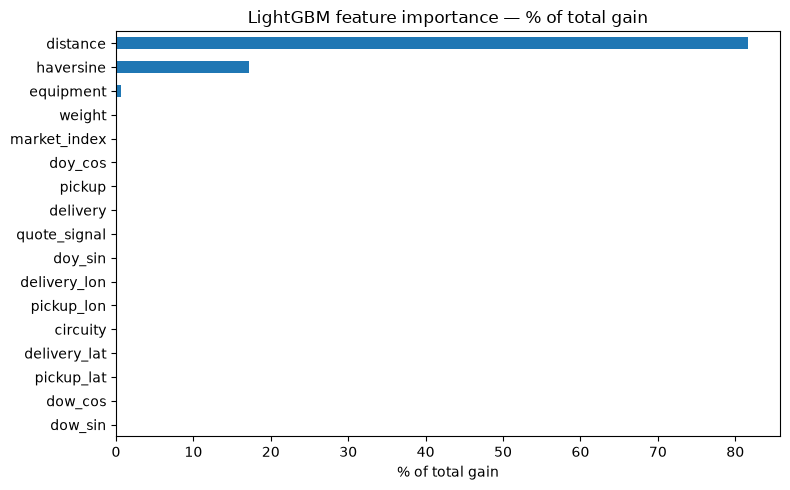

In [23]:
# Feature importance by GAIN (error reduction), not split count
gain = pd.Series(outer_model.booster_.feature_importance("gain"), index=FEATURES)
(gain / gain.sum() * 100).sort_values().plot(
    kind="barh", figsize=(8, 5), title="LightGBM feature importance — % of total gain"
)
plt.xlabel("% of total gain")
plt.tight_layout()
plt.show()

**A note on importance metrics:** LightGBM's default *split-count* importance ranks `pickup`/`delivery` near the top, but that is an artifact; high-cardinality categoricals (64+ cities) offer many candidate split points, so trees split on them frequently even when each split reduces error only marginally. *Gain* importance (total error reduction attributable to each feature) is the honest metric, and it tells a very different story: the distance geometry dominates.

## 7. Final model and validation predictions

After recording the untouched outer-test results, the frozen pipeline is retrained on all available January–October development data.

At this stage, September–October labels may be included because model assessment has finished and the goal is to produce the strongest possible final November–December predictions.

The final fit uses:

* The hyperparameters selected from the pre-September inner folds
* The median inner-fold boosting-round count
* The same fixed outlier threshold
* The same feature definitions
* The same categorical-handling procedure

The model is not retuned after including September–October.

`load_id` is never used as a predictive feature. It is used only to align predictions with the supplied template.


In [24]:
full_fit = train.copy()

full_keep_mask = rpm_outlier_mask(full_fit)

full_fit = full_fit.loc[full_keep_mask].copy()


(
    full_fit,
    val_for_model,
) = align_categorical_levels(
    full_fit,
    val,
)


FINAL_PARAMS = {
    **BEST_PARAMS,
    "objective": "regression",
    "metric": "l1",
    "n_estimators": (FINAL_N_ESTIMATORS),
    "subsample_freq": 1,
    "random_state": RANDOM_STATE,
    "deterministic": True,
    "force_col_wise": True,
    "n_jobs": -1,
    "verbosity": -1,
}


final_model = lgb.LGBMRegressor(**FINAL_PARAMS)


final_model.fit(
    full_fit[FEATURES],
    np.log(full_fit[TARGET]),
    categorical_feature=(CATEGORICAL_FEATURES),
)


validation_prediction = np.exp(final_model.predict(val_for_model[FEATURES]))


prediction_by_id = pd.DataFrame(
    {
        "load_id": (val_for_model["load_id"]),
        "predicted_rate": np.round(
            validation_prediction,
            2,
        ),
    }
)


submission = template[["load_id"]].merge(
    prediction_by_id,
    on="load_id",
    how="left",
    validate="one_to_one",
)


assert len(submission) == 12_000
assert submission["load_id"].is_unique

assert submission["predicted_rate"].notna().all()

assert np.isfinite(submission["predicted_rate"]).all()

assert (submission["predicted_rate"] > 0).all()


submission.to_csv(
    "validation_predictions.csv",
    index=False,
)


print(
    f"Final model trained on "
    f"{len(full_fit):,} rows with "
    f"{FINAL_N_ESTIMATORS:,} trees."
)

print(submission["predicted_rate"].describe())

submission.head()

Final model trained on 47,328 rows with 3,794 trees.
count    12000.000000
mean      2252.037877
std       1301.004514
min        195.350000
25%       1213.785000
50%       1942.225000
75%       3196.060000
max       6557.280000
Name: predicted_rate, dtype: float64


,load_id,predicted_rate
0,TE-000001,818.34
1,TE-000002,5008.49
2,TE-000003,5218.43
3,TE-000004,3981.93
4,TE-000005,1791.59


## 8. Fixed December lane predictions

The supplied December chart file fixes the following business inputs:

* Pickup: Lexington
* Delivery: Fort Wayne
* Distance: 360 miles
* Equipment: Dry Van
* Weight: 32,000 lb

Only the date changes from December 1 through December 31.

The chart file does not contain coordinates, `market_index`, or `quote_signal`, although these variables are part of the final feature set.

Coordinates are obtained from the consistent city-coordinate mapping in the development data.

For `market_index` and `quote_signal`, the final validation file contains unlabeled December loads on every required date. I use the daily mean of each signal as a date-level market estimate. No final `posted_rate` labels are available or used.

The six visible business inputs remain fixed, while the derived market signals vary by date. This assumption is disclosed because the effective prediction inputs contain more information than the seven columns shown in the chart file.


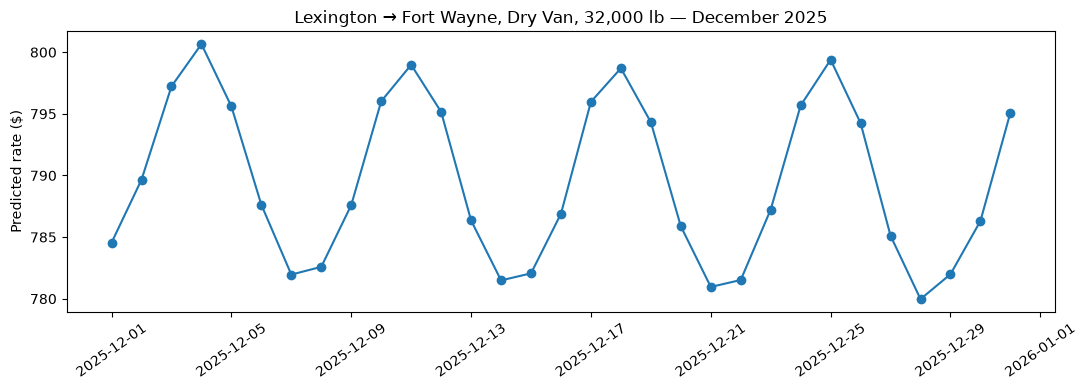

,pickup,delivery,distance,equipment,weight,date,predicted_rate
0,Lexington,Fort Wayne,360,Dry Van,32000,2025-12-01,784.55
1,Lexington,Fort Wayne,360,Dry Van,32000,2025-12-02,789.66
2,Lexington,Fort Wayne,360,Dry Van,32000,2025-12-03,797.23
3,Lexington,Fort Wayne,360,Dry Van,32000,2025-12-04,800.66
4,Lexington,Fort Wayne,360,Dry Van,32000,2025-12-05,795.60


In [25]:
december = december_raw.copy()


pickup_coordinates = (
    train_raw
    .drop_duplicates("pickup")
    .set_index("pickup")[
        [
            "pickup_lat",
            "pickup_lon",
        ]
    ]
)

delivery_coordinates = (
    train_raw
    .drop_duplicates("delivery")
    .set_index("delivery")[
        [
            "delivery_lat",
            "delivery_lon",
        ]
    ]
)


december["pickup_lat"] = (
    pickup_coordinates.loc[
        "Lexington",
        "pickup_lat",
    ]
)

december["pickup_lon"] = (
    pickup_coordinates.loc[
        "Lexington",
        "pickup_lon",
    ]
)

december["delivery_lat"] = (
    delivery_coordinates.loc[
        "Fort Wayne",
        "delivery_lat",
    ]
)

december["delivery_lon"] = (
    delivery_coordinates.loc[
        "Fort Wayne",
        "delivery_lon",
    ]
)


daily_signals = (
    val_raw
    .groupby("date")[
        [
            "market_index",
            "quote_signal",
        ]
    ]
    .mean()
)


december = december.merge(
    daily_signals,
    left_on="date",
    right_index=True,
    how="left",
    validate="many_to_one",
)


assert (
    december[
        [
            "market_index",
            "quote_signal",
        ]
    ]
    .notna()
    .all()
    .all()
)


december_features = (
    add_features(december)
)


(
    _,
    december_for_model,
) = align_categorical_levels(
    full_fit,
    december_features,
)


december_prediction = np.exp(
    final_model.predict(
        december_for_model[
            FEATURES
        ]
    )
)


december_output = (
    december_raw.copy()
)

december_output[
    "predicted_rate"
] = np.round(
    december_prediction,
    2,
)

december_output["date"] = (
    december_output["date"]
    .dt.strftime("%Y-%m-%d")
)


december_output.to_csv(
    "data/december_chart_inputs.csv",
    index=False,
)


plt.figure(
    figsize=(11, 4)
)

plt.plot(
    pd.to_datetime(
        december_output["date"]
    ),
    december_output[
        "predicted_rate"
    ],
    marker="o",
)

plt.title(
    "Lexington → Fort Wayne, "
    "Dry Van, 32,000 lb — "
    "December 2025"
)

plt.ylabel(
    "Predicted rate ($)"
)

plt.xticks(
    rotation=35
)

plt.tight_layout()
plt.show()

december_output.head()

## 9. Structural validation with the supplied scorer

In [26]:
!python score.py \
    --predictions validation_predictions.csv \
    --december-predictions data/december_chart_inputs.csv

Validated 12,000 final predictions.
Validated 31 fixed December predictions.
Created chart: scorer_results/candidate_december.png
Final validation metrics are calculated by Spotter after submission.


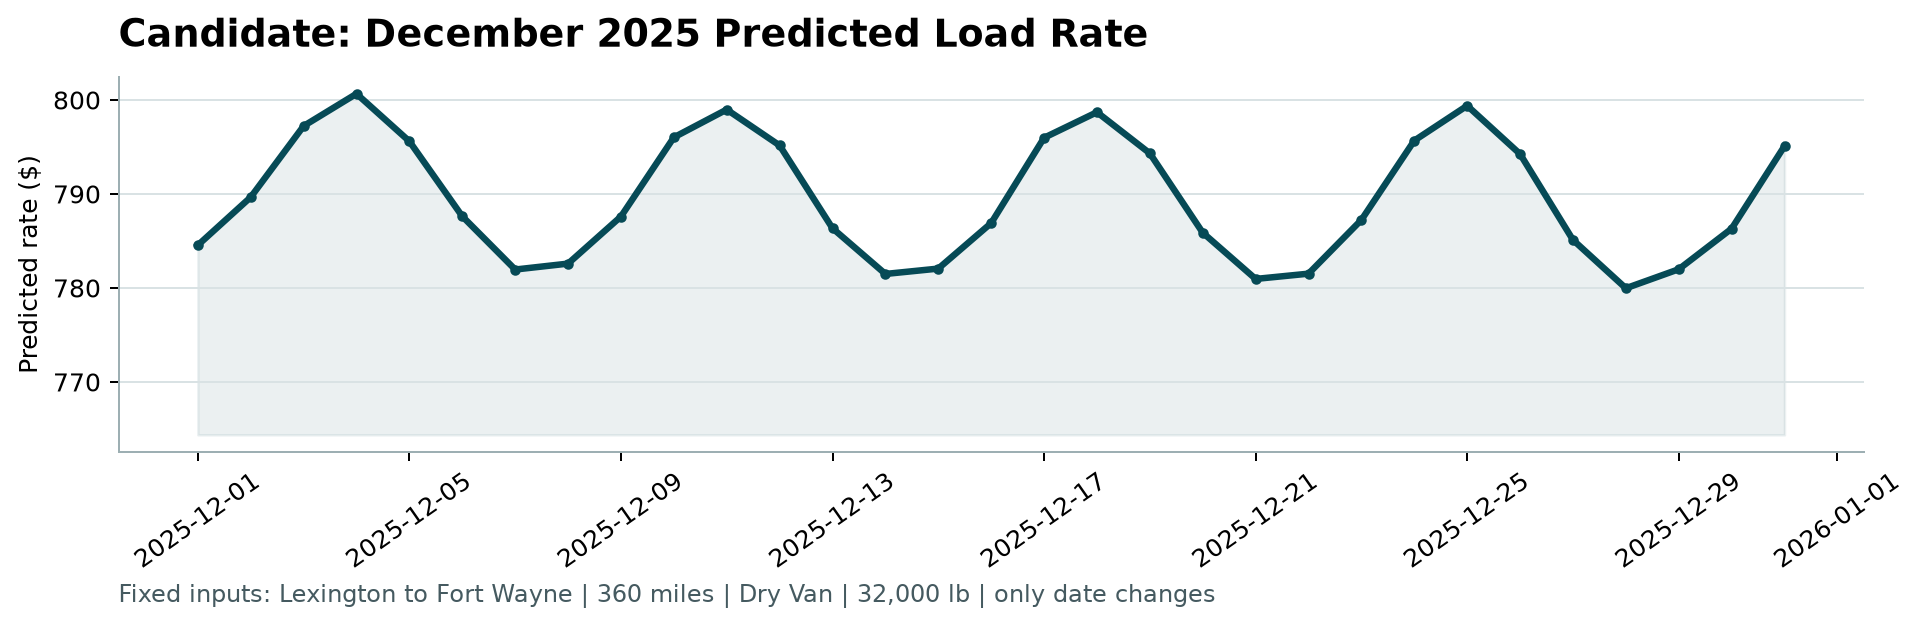

In [27]:
from IPython.display import Image

Image(
    "scorer_results/"
    "candidate_december.png"
)

## Summary

* **Forecasting structure:** Development data covers January–October, while final predictions cover November–December. All validation is therefore forward-only.

* **Data quality:** Negative weights are corrected using their absolute magnitude. Suspected log-RPM anomalies are excluded from fitting only, with detection statistics calculated independently inside every training fold.

* **Features:** The model uses route geometry, circuity, weight, equipment, city information, numeric coordinates, market signals, and cyclic calendar features.

* **Model selection:** Hyperparameters and boosting rounds are selected using June, July, and August inner validation folds. September–October is not accessed during tuning.

* **Temporal assessment:** The frozen pipeline achieved September–October MAE of **$119.89**, RMSE of **$637.10**, and R² of **0.8257**.

* **Final training:** After model assessment, the fixed pipeline is retrained on all January–October labeled rows and applied to all 12,000 November–December loads.

* **Outputs:** `validation_predictions.csv` and the completed `data/december_chart_inputs.csv` both pass the supplied structural scorer.
